## Seattle Crime Data Analysis (2025)

In [27]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import rcParams
from pandas.api.types import CategoricalDtype
import warnings
import os 

import folium
from folium.plugins import HeatMap
import ydata_profiling

rcParams["figure.figsize"] = 20,9
warnings.filterwarnings("ignore")

#### Import all data and drop the rows with missing values

In [3]:
print(os.listdir("/Users/bri/Downloads/crimes-in-seattle"))

dataframe = pd.read_csv("/Users/bri/Downloads/crimes-in-seattle/SPD_Crime_Data__2008-Present_20260317.csv")
dataframe.head()

['crimes-in-seattle.ipynb', '.DS_Store', 'workspace.code-workspace', 'LICENSE', 'SPD_Crime_Data__2008-Present_20260317.csv', 'README.md', '.gitignore', '.git']


,Report Number,Report DateTime,Offense ID,Offense Date,NIBRS Group AB,NIBRS Crime Against Category,Offense Sub Category,Shooting Type Group,Block Address,Latitude,Longitude,Beat,Precinct,Sector,Neighborhood,Reporting Area,Offense Category,NIBRS Offense Code Description,NIBRS_offense_code
0,2009-116925,2009 Apr 07 12:33:00 PM,7640542762,2009 Apr 04 09:00:00 PM,A,PROPERTY,LARCENY-THEFT,-,6XX BLOCK OF STEWART ST,47.61395514,-122.336584688501,M2,West,M,-,12783,PROPERTY CRIME,Theft From Motor Vehicle,23F
1,2020-338921,2020 Dec 08 12:39:49 PM,18850531859,2020 Dec 05 02:30:00 AM,A,PROPERTY,BURGLARY,-,69XX BLOCK OF M L KING JR WAY S,47.53978423,-122.282429895144,S2,South,S,BRIGHTON/DUNLAP,10971,PROPERTY CRIME,Burglary/Breaking & Entering,220
2,2013-068517,2013 Feb 28 10:12:00 AM,7633645932,2013 Feb 27 07:00:00 PM,A,PROPERTY,LARCENY-THEFT,-,36XX BLOCK OF 13TH AVE W,47.6530852,-122.373596946735,Q2,West,Q,-,1156,PROPERTY CRIME,Theft of Motor Vehicle Parts or Accessories,23G
3,2018-903268,2018 Apr 14 10:55:00 PM,7626378669,2018 Apr 14 09:40:00 PM,A,PROPERTY,LARCENY-THEFT,-,14TH AVE NW / NW 52ND ST,47.66643106,-122.373590892794,B2,North,B,BALLARD SOUTH,2449,PROPERTY CRIME,Theft From Motor Vehicle,23F
4,2011-322743,2011 Oct 01 06:48:00 AM,7628482368,2011 Oct 01 06:48:00 AM,A,PERSON,ASSAULT OFFENSES,-,1XX BLOCK OF PIKE ST,47.609053,-122.339459,M1,West,M,-,12451,ALL OTHER,Intimidation,13C


### Data Cleaning

In [ ]:
#Drop unwanted columns
cols_to_drop = ["NIBRS Group AB", "Block Address", "Sector", 
                "Shooting Type Group", "NIBRS_offense_code"]

df2 = dataframe.drop(cols_to_drop, axis=1)

#filter data by date
df2['Report DateTime'] = pd.to_datetime(df2['Report DateTime'])
df2['Report DateTime'] = pd.to_datetime(df2['Report DateTime'])

df2 = df2[df2['Report DateTime'].dt.year == 2025]

print(df2.columns)


Index(['Report Number', 'Report DateTime', 'Offense ID', 'Offense Date',
       'NIBRS Crime Against Category', 'Offense Sub Category', 'Latitude',
       'Longitude', 'Beat', 'Precinct', 'Neighborhood', 'Reporting Area',
       'Offense Category', 'NIBRS Offense Code Description'],
      dtype='object')


In [ ]:
#rename certain columns
rename = {'Report Number' : 'ReportNumber', 'Offense ID' : 'OffenseID', 'Offense Date' : 'OffenseDate', 
          'NIBRS Crime Against Category' : 'CrimeAgainst', 'Offense Sub Category' : 'OffenseSubCategory',
           'Reporting Area' : 'ReportingArea', 'Offense Category' : 'OffenseCategory', 
           'NIBRS Offense Code Description' : 'OffenseDescription' }
df2.rename(index = str, columns= rename, inplace = True)

#Recategorize certain elements
df2['Report DateTime'] = pd.to_datetime(df2['Report DateTime'])
df2['OffenseDate'] = pd.to_datetime(df2['OffenseDate'])

df2.ReportNumber = df2.ReportNumber.astype(CategoricalDtype())
df2.Beat = df2.Beat.astype(CategoricalDtype())
df2.OffenseID  = df2.OffenseID .astype(int)
df2.CrimeAgainst = df2.CrimeAgainst.astype(CategoricalDtype())
df2.OffenseCategory = df2.OffenseCategory.astype(CategoricalDtype())
df2.OffenseSubCategory = df2.OffenseSubCategory.astype(CategoricalDtype())
df2.ReportingArea = df2.ReportingArea.astype(CategoricalDtype())
df2.Precinct = df2.Precinct.astype(CategoricalDtype())
df2.Neighborhood = df2.Neighborhood.astype(CategoricalDtype())

df2['Latitude'] = pd.to_numeric(df2['Latitude'], errors='coerce')
df2['Longitude'] = pd.to_numeric(df2['Longitude'], errors='coerce')
df2 = df2.dropna()


<class 'pandas.core.frame.DataFrame'>
Index: 65814 entries, 5 to 1518730
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ReportNumber        65814 non-null  category      
 1   Report DateTime     65814 non-null  datetime64[ns]
 2   OffenseID           65814 non-null  int64         
 3   OffenseDate         65814 non-null  datetime64[ns]
 4   CrimeAgainst        65814 non-null  category      
 5   OffenseSubCategory  65814 non-null  category      
 6   Latitude            65814 non-null  float64       
 7   Longitude           65814 non-null  float64       
 8   Beat                65814 non-null  category      
 9   Precinct            65814 non-null  category      
 10  Neighborhood        65814 non-null  category      
 11  ReportingArea       65814 non-null  category      
 12  OffenseCategory     65814 non-null  category      
 13  OffenseDescription  65814 non-null  object       

### Exploratory Data Analysis

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65814 entries, 5 to 1518730
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ReportNumber        65814 non-null  category      
 1   Report DateTime     65814 non-null  datetime64[ns]
 2   OffenseID           65814 non-null  int64         
 3   OffenseDate         65814 non-null  datetime64[ns]
 4   CrimeAgainst        65814 non-null  category      
 5   OffenseSubCategory  65814 non-null  category      
 6   Latitude            65814 non-null  float64       
 7   Longitude           65814 non-null  float64       
 8   Beat                65814 non-null  category      
 9   Precinct            65814 non-null  category      
 10  Neighborhood        65814 non-null  category      
 11  ReportingArea       65814 non-null  category      
 12  OffenseCategory     65814 non-null  category      
 13  OffenseDescription  65814 non-null  object       

#### Offense Category Type Count

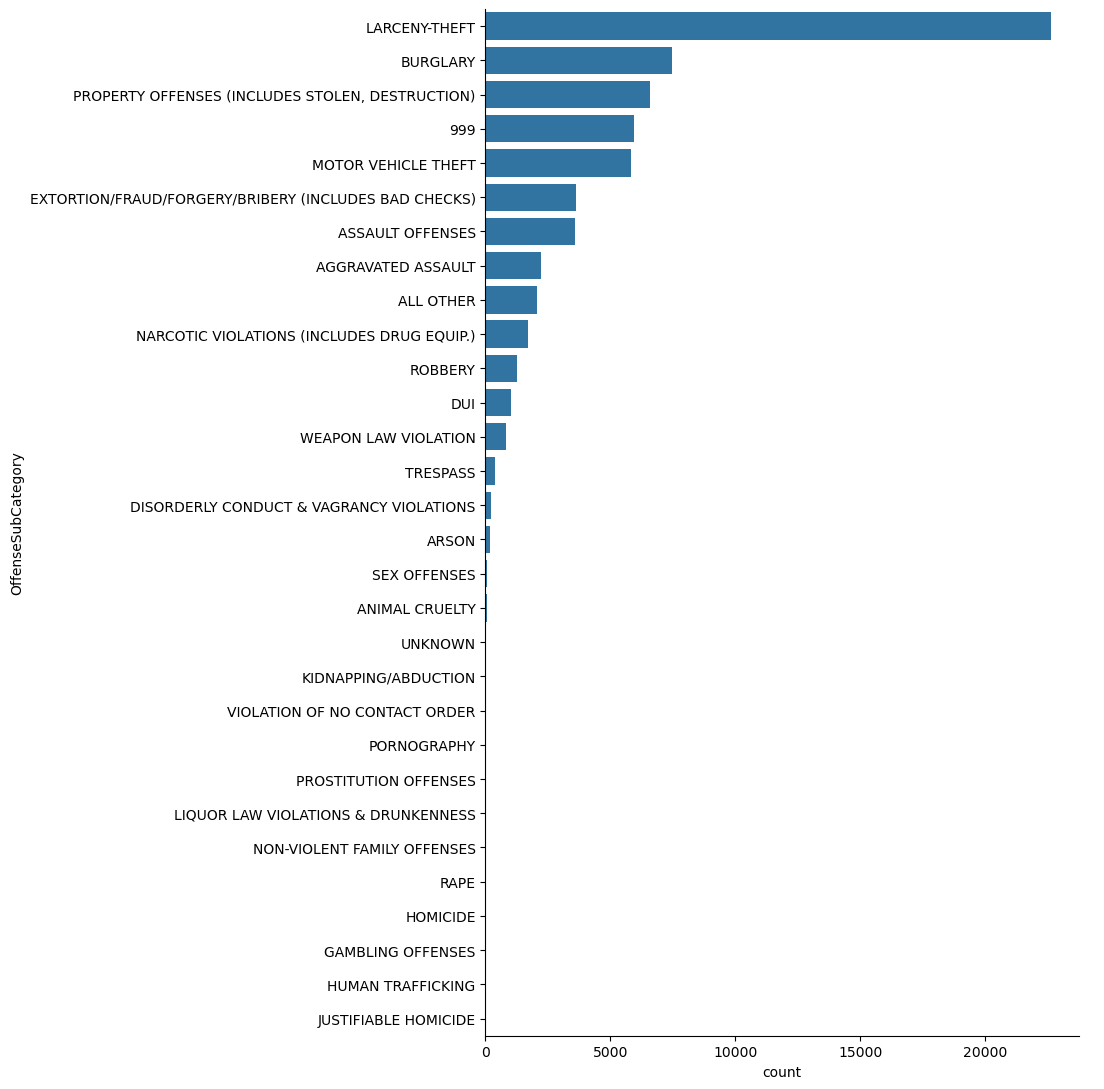

In [ ]:
sns.catplot(y='OffenseSubCategory',
            kind='count',
            height=11, 
            aspect=1,
            order=df2.OffenseSubCategory.value_counts().index,
            data=df2)


#### Crime Distribution in Seattle by Neighborhood

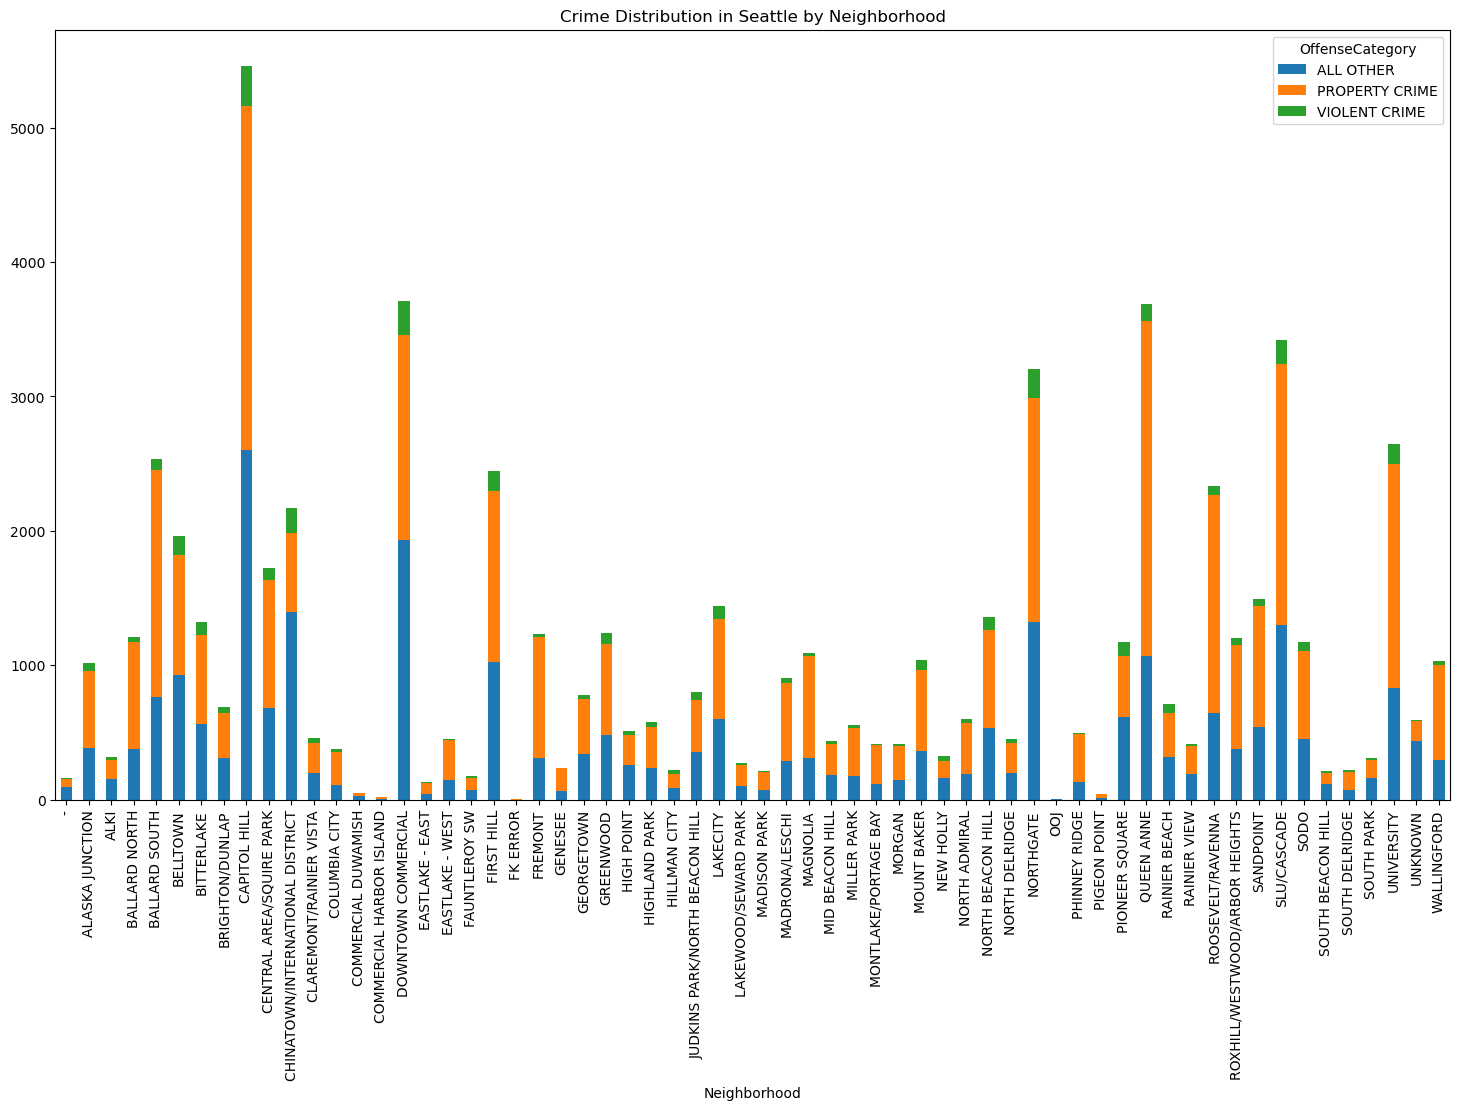

In [ ]:
pd.crosstab(df2['Neighborhood'], df2['OffenseCategory']).plot(kind='bar', stacked=True, figsize=(18,10))
plt.title("Crime Distribution in Seattle by Neighborhood")
plt.show()

#### Crimes in Seattle over 10 years

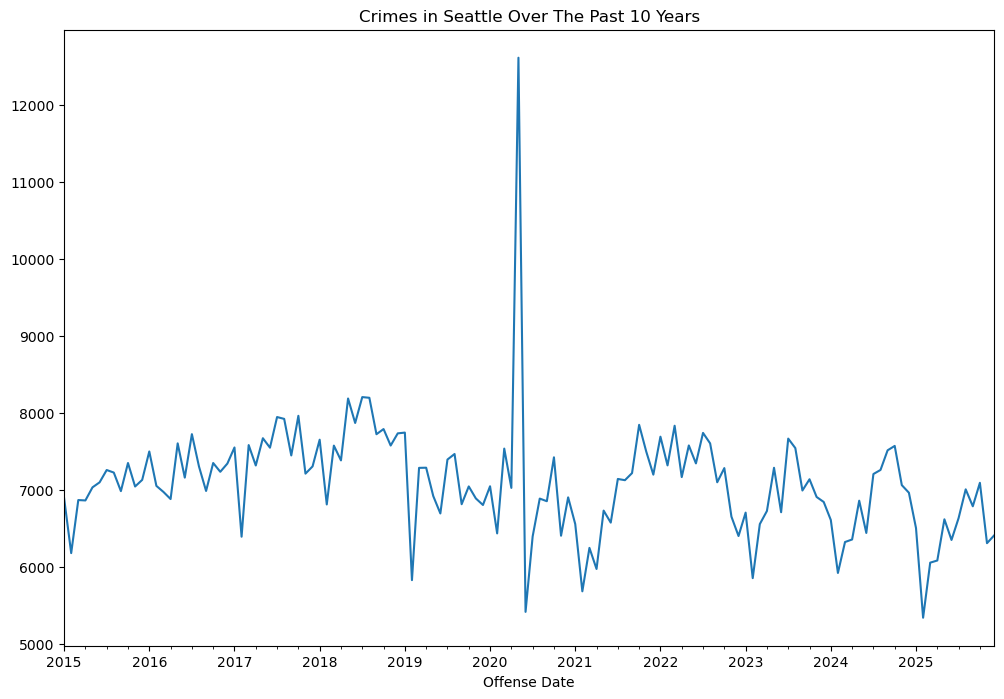

In [ ]:
dataframe['Offense Date'] = pd.to_datetime(dataframe['Offense Date'])
ten_year_crimes = dataframe[dataframe['Offense Date'].between('2015-01-01', '2025-12-31')]
ten_year_crimes = ten_year_crimes.set_index('Offense Date').resample('M').size()

ten_year_crimes.plot(figsize=(12,8))
plt.title("Crimes in Seattle over 10 Years")
plt.show()

## GIS (Geographic Information Systems)

### Heat Map of Crimes in Capitol Hill

In [29]:
cap_hill_crimes = df2.loc[
    df2.Neighborhood == 'CAPITOL HILL',
    ['Latitude', 'Longitude']
]

# Drop invalid rows
cap_hill_crimes = cap_hill_crimes.dropna()

# Create Heat Map
heatmap = folium.Map(
    location=[47.6061, -122.3328], #Capitol Hill Coordinates,
    zoom_start=13
)

# Marker in Seattle 
folium.CircleMarker(
    [47.6236, -122.3210],
    radius=20,
    fill_color="#b22222",
    popup='Larceny-Theft',
    color='red',
).add_to(heatmap)

HeatMap(data=cap_hill_crimes, radius=25).add_to(heatmap)
heatmap.save("caphill_crime_heatmap.html")

#### Crime Heatmap Link
https://brianaowusu.github.io/cap_hill_heatmap/caphill_crime_heatmap.html

### Heat Map of Crimes in Seattle Overall

In [30]:
seattle_crimes = df2[['Latitude', 'Longitude']]

seattle_crimes.dropna

# Create Heat Map
heatmap2=folium.Map(location=[47.6061, -122.3328], #Seattle coordinates
                zoom_start=11)

# Marker in Seattle
folium.CircleMarker([47.6061, -122.3328],
                        radius=70,
                        fill_color="#b22222",
                        popup='Larceny-Theft',
                        color='red',
                       ).add_to(heatmap2)


HeatMap(data=seattle_crimes, radius=16).add_to(heatmap2)
heatmap2.save("seattle_crime_heatmap.html")

#### Crime Heatmap Preview
https://brianaowusu.github.io/seattle-crime-heatmap/seattle_crime_heatmap.html